# Reload the raw dataset

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Dataset path:", path)


print(os.listdir(path))

c:\Users\Marienne\OneDrive\Documents\personal project\BuildersLab project\credict risk prediction\Credit-Risk-Default\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\Marienne\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3
['accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv.gz']


In [3]:
import pandas as pd
import os
# Download dataset
path = kagglehub.dataset_download("wordsforthewise/lending-club")

df = pd.read_csv(
    os.path.join(path, "accepted_2007_to_2018Q4.csv.gz"),
    low_memory=False
)

## Define target variable

Good customer:
Fully Paid → 1,076,751 records

Bad customer:
We will combine the following categories into a single “bad customer” class:

Charged Off :268,559 records
Default : 40 records
Late (31–120 days) : 21,467 records
The remaining categories will be removed from the analysis:

Late (16–30 days) : 4,349 records

In [4]:
# clean loan_status column
# remove rows that don't fit either class


remove_status = ['Current', 'Late (16-30 days)', 'In Grace Period',
                  'Does not meet the credit policy. Status:Fully Paid',
                  'Does not meet the credit policy. Status:Charged Off']

df = df[~df['loan_status'].isin(remove_status)]

# map to binary target
bad_status = ['Charged Off', 'Default', 'Late (31-120 days)']

df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x in bad_status else 0)

df['loan_status'].value_counts()



loan_status
0    1076784
1     290066
Name: count, dtype: int64

# Data Leakage 

In [ ]:
to_drop = [
    # Post-approval funding
    'funded_amnt', 'funded_amnt_inv',
    # LC internal scoring
    'int_rate', 'installment', 'grade', 'sub_grade',

    # Post-origination payments
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'pymnt_plan',
    # Post-origination credit
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    # Hardship
    'hardship_flag', 'hardship_reason', 'hardship_status', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
    'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount','hardship_type', 'deferral_term', 'hardship_length',
    # Settlement
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage',
    'settlement_term',
]

#to_drop = [col for col in to_drop if col in df.columns]
df = df.drop(columns=to_drop)

print(f"Dropped  : {len(to_drop)} columns")
print(f"Remaining: {len(df.columns)} columns")

Dropped  : 41 columns
Remaining: 110 columns


POST-APPROVAL FUNDING
funded_amnt: The amount committed by investors - only known after approval decision, not at application time
funded_amnt_inv: The amount funded by investors - post-approval, not available at application

LC INTERNAL RISK SCORING
int_rate: Interest rate assigned by LendingClub - set after their internal model runs, not a borrower attribute
installment: Monthly payment amount - derived from int_rate + term + loan_amnt, post-decision calculation
grade: LendingClub's internal risk grade (A-G) - assigned by LC's own model, not a raw borrower attribute
sub_grade: More granular version of LC's grade (A1-G5) - same issue as grade


POST-ORIGINATION PAYMENT BEHAVIOR
out_prncp: Remaining outstanding principal - only exists and updates during repayment period
out_prncp_inv: Investor's portion of remaining principal - same issue as out_prncp
total_pymnt: Total amount received so far from borrower - accumulates after loan is issued
total_pymnt_inv: Total payments received by investors - post-origination accumulation
total_rec_prncp: Total principal received to date - only known during/after repayment
total_rec_int: Total interest received to date - only known during/after repayment
total_rec_late_fee: Total late fees received - only exists after borrower misses payments
recoveries: Amount recovered after charge-off - only populated after borrower defaults
collection_recovery_fee: Fee charged during recovery process - only after default and collections
last_pymnt_d: Date of the last payment made - only exists after loan is active and payments begin
last_pymnt_amnt: Amount of the last payment - post-origination, only known after payments start
next_pymnt_d: Next scheduled payment date - only scheduled after loan is issued and active
pymnt_plan: Whether borrower is on a payment modification plan - post-origination event

POST-ORIGINATION CREDIT UPDATES
last_credit_pull_d: Date LC last pulled borrower's credit - happens after loan is already active
last_fico_range_high: Most recent FICO high - updated throughout loan life, not the application-time score
last_fico_range_low: Most recent FICO low - same issue as last_fico_range_high

HARDSHIP PROGRAM (POST-ORIGINATION EVENT)
hardship_flag: Indicates if borrower entered a hardship plan - hardship only declared during repayment
hardship_reason: Reason borrower cited for hardship - post-origination, only exists if hardship declared
hardship_status: Current status of the hardship plan - post-origination event tracking
hardship_amount: Amount deferred under hardship plan - post-origination financial adjustment
hardship_start_date: When the hardship plan began - post-origination date
hardship_end_date: When the hardship plan ended - post-origination date
payment_plan_start_date: When the modified payment plan started - post-origination modification
hardship_dpd: Days past due during hardship period - post-origination repayment behavior
hardship_loan_status: Loan status during hardship - directly encodes post-origination outcome
orig_projected_additional_accrued_interest: Projected interest during hardship deferral - post-origination calculation
hardship_payoff_balance_amount: Loan balance during hardship - post-origination balance
hardship_last_payment_amount: Last payment made during hardship - post-origination payment behavior

DEBT SETTLEMENT (POST-DEFAULT EVENT)
debt_settlement_flag: Indicates borrower entered debt settlement - only flagged after default
debt_settlement_flag_date: Date settlement flag was set - post-default timestamp
settlement_status: Current status of the settlement negotiation - post-default process
settlement_date: Date settlement was reached - post-default event
settlement_amount: Amount borrower agreed to settle for - post-default negotiation result
settlement_percentage: Percentage of balance settled - post-default calculation
settlement_term: Repayment terms of the settlement - post-default agreement

# Inconsistentvaluesandincorrectdatatypes

In [6]:
# Full numeric description - no truncation
import pandas as pd
pd.set_option('display.max_rows', 200)

desc = df.select_dtypes(include='float64').describe().T
print(desc.to_string())

                                         count           mean            std     min       25%        50%        75%          max
member_id                                  0.0            NaN            NaN     NaN       NaN        NaN        NaN          NaN
loan_amnt                            1366817.0   14459.653011    8738.443267   500.0   8000.00   12000.00   20000.00     40000.00
annual_inc                           1366817.0   76259.794609   70313.623641     0.0  45760.00   65000.00   90000.00  10999200.00
dti                                  1366419.0      18.311995      11.317034    -1.0     11.80      17.63      24.09       999.00
delinq_2yrs                          1366817.0       0.318443       0.879573     0.0      0.00       0.00       0.00        39.00
fico_range_low                       1366817.0     696.124525      31.816170   625.0    670.00     690.00     710.00       845.00
fico_range_high                      1366817.0     700.124664      31.816822   629.0    67

In [7]:
for col in df.select_dtypes(include='object').columns:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique <= 20:
        print(df[col].value_counts())
    print()

C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\1085365390.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


id: 1366850 unique values

term: 2 unique values
term
36 months    1033242
60 months     333575
Name: count, dtype: int64

emp_title: 381808 unique values

emp_length: 11 unique values
emp_length
10+ years    448782
2 years      123714
< 1 year     110094
3 years      109396
1 year        89937
5 years       85473
4 years       81971
6 years       63654
8 years       61459
7 years       60395
9 years       51575
Name: count, dtype: int64

home_ownership: 6 unique values
home_ownership
MORTGAGE    674904
RENT        543891
OWN         147526
ANY            304
OTHER          144
NONE            48
Name: count, dtype: int64

verification_status: 3 unique values
verification_status
Source Verified    530338
Verified           425051
Not Verified       411428
Name: count, dtype: int64

issue_d: 139 unique values

url: 1366817 unique values

desc: 122012 unique values

purpose: 14 unique values
purpose
debt_consolidation    792817
credit_card           299299
home_improvement       88948
ot

Let's fix it

In [8]:
# 1. DATA TYPE FIXES

# term: stored as "36 months" string -> extract number -> convert to integer
df['term'] = df['term'].str.replace(' months', '').astype('Int64')

# emp_length: stored as "10+ years", "< 1 year" etc -> extract number -> convert to float
# "< 1 year" becomes 0, "10+ years" becomes 10
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': '0',
    '10+ years': '10'
})
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

# issue_d: stored as "Mar-2016" string -> convert to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

# earliest_cr_line: stored as "Aug-2001" string -> convert to datetime
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')

# sec_app_earliest_cr_line: same string date issue as earliest_cr_line but for co-borrower
df['sec_app_earliest_cr_line'] = pd.to_datetime(df['sec_app_earliest_cr_line'], format='%b-%Y', errors='coerce')

# initial_list_status: values are lowercase "w" and "f" while all other columns use uppercase
df['initial_list_status'] = df['initial_list_status'].str.upper()

# disbursement_method: "DirectPay" uses CamelCase while "Cash" is plain text -> standardize to uppercase
df['disbursement_method'] = df['disbursement_method'].str.upper()



In [9]:
# IMPOSSIBLE VALUES — UTILIZATION COLUMNS (cannot exceed 100%)

# revol_util: max is 892% which is impossible for a utilization rate
# values above 100 are data errors -> cap at 100, flag extremes as separate category
df['revol_util_flag'] = (df['revol_util'] > 100).astype(int)
df['revol_util'] = df['revol_util'].clip(upper=100)

# il_util: max is 558 which is impossible for installment loan utilization
# same treatment as revol_util
df['il_util_flag'] = (df['il_util'] > 100).astype(int)
df['il_util'] = df['il_util'].clip(upper=100)

# all_util: max is 204% which is impossible for overall utilization
# same treatment
df['all_util_flag'] = (df['all_util'] > 100).astype(int)
df['all_util'] = df['all_util'].clip(upper=100)

# bc_util: max is 339% which is impossible for bank card utilization
# same treatment
df['bc_util_flag'] = (df['bc_util'] > 100).astype(int)
df['bc_util'] = df['bc_util'].clip(upper=100)

# sec_app_revol_util: max is 235% which is impossible for co-borrower revolving utilization
# same treatment
df['sec_app_revol_util_flag'] = (df['sec_app_revol_util'] > 100).astype(int)
df['sec_app_revol_util'] = df['sec_app_revol_util'].clip(upper=100)



In [10]:
 #IMPOSSIBLE VALUES — DTI

import numpy as np
# dti: min is -1.0 (impossible, DTI can never be negative)
# and max is 999 (clearly a system placeholder for unknown/error)
# negative values -> set to NaN (genuinely invalid)
# 999 -> set to NaN (placeholder, not a real value)
# flag both cases so the model knows data was missing/corrupt here
# any DTI above a realistic ceiling (e.g. 200) should be treated as error
df['dti_flag'] = ((df['dti'] < 0) | (df['dti'] > 200)).astype(int)
df['dti'] = df['dti'].where((df['dti'] >= 0) & (df['dti'] <= 200), other=np.nan)


In [11]:
# PLACEHOLDER VALUES — 9,999,999 SENTINEL VALUES


# total_rev_hi_lim: max is 9,999,999 which is a system placeholder
# meaning "no limit" or "unknown", not a real credit limit
# replace with NaN and flag so model knows these were special cases
df['total_rev_hi_lim_flag'] = (df['total_rev_hi_lim'] == 9999999).astype(int)
df['total_rev_hi_lim'] = df['total_rev_hi_lim'].replace(9999999, np.nan)

# tot_hi_cred_lim: same 9,999,999 placeholder pattern as total_rev_hi_lim
df['tot_hi_cred_lim_flag'] = (df['tot_hi_cred_lim'] == 9999999).astype(int)
df['tot_hi_cred_lim'] = df['tot_hi_cred_lim'].replace(9999999, np.nan)

# mo_sin_old_il_acct: max is 999 which is a placeholder for unknown/missing
# not a real value of 999 months (83 years)
df['mo_sin_old_il_acct_flag'] = (df['mo_sin_old_il_acct'] == 999).astype(int)
df['mo_sin_old_il_acct'] = df['mo_sin_old_il_acct'].replace(999, np.nan)


C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\208526215.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_rev_hi_lim_flag'] = (df['total_rev_hi_lim'] == 9999999).astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\208526215.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tot_hi_cred_lim_flag'] = (df['tot_hi_cred_lim'] == 9999999).astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\208526215.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

In [12]:
# RARE CATEGORIES — HOME OWNERSHIP
# home_ownership: ANY (304 rows), OTHER (144 rows), NONE (48 rows)
# are too rare and vague to be meaningful for credit risk modeling
# group all three into a single "OTHER" category
df['home_ownership'] = df['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})

In [13]:

# RARE CATEGORIES — ADDR_STATE


# addr_state: Iowa (IA) has only 7 rows out of 1.3 million
# extremely underrepresented and will cause issues with encoding
# flag states with fewer than 100 rows as "OTHER"
state_counts = df['addr_state'].value_counts()
rare_states = state_counts[state_counts < 100].index.tolist()
df['addr_state'] = df['addr_state'].replace(rare_states, 'OTHER')

In [14]:
# VERIFICATION


print(" Data Type Check ")
print(df[['term', 'emp_length', 'issue_d', 'earliest_cr_line']].dtypes)

print("Utilization Columns (should all be <= 100)")
for col in ['revol_util', 'il_util', 'all_util', 'bc_util', 'sec_app_revol_util']:
    if col in df.columns:
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")

print("\ DTI Check ")
print(f"dti: min={df['dti'].min()}, max={df['dti'].max()}, nulls={df['dti'].isna().sum()}")

print(" Placeholder Check")
print(f"total_rev_hi_lim 9999999 remaining: {(df['total_rev_hi_lim'] == 9999999).sum()}")
print(f"tot_hi_cred_lim 9999999 remaining : {(df['tot_hi_cred_lim'] == 9999999).sum()}")

print(" home_ownership categories ")
print(df['home_ownership'].value_counts())

print("\n=== Flag columns created ===")
flag_cols = [col for col in df.columns if col.endswith('_flag')]
print(flag_cols)

print(f"\nFinal shape: {df.shape}")

<>:12: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:12: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\1895637873.py:12: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  print("\ DTI Check ")


 Data Type Check 
term                         Int64
emp_length                 float64
issue_d             datetime64[us]
earliest_cr_line    datetime64[us]
dtype: object
Utilization Columns (should all be <= 100)
revol_util: min=0.0, max=100.0
il_util: min=0.0, max=100.0
all_util: min=0.0, max=100.0
bc_util: min=0.0, max=100.0
sec_app_revol_util: min=0.0, max=100.0
\ DTI Check 
dti: min=0.0, max=199.72, nulls=650
 Placeholder Check
total_rev_hi_lim 9999999 remaining: 0
tot_hi_cred_lim 9999999 remaining : 0
 home_ownership categories 
home_ownership
MORTGAGE    674904
RENT        543891
OWN         147526
OTHER          496
Name: count, dtype: int64

=== Flag columns created ===
['revol_util_flag', 'il_util_flag', 'all_util_flag', 'bc_util_flag', 'sec_app_revol_util_flag', 'dti_flag', 'total_rev_hi_lim_flag', 'tot_hi_cred_lim_flag', 'mo_sin_old_il_acct_flag']

Final shape: (1366850, 119)


## Train/ test split


In [15]:
from sklearn.model_selection import train_test_split
# Separate features and target
X = df.drop(columns='loan_status')
y = df['loan_status']

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


## 1. Missing   Values Handling



**Approach:** for every column with missing values, we ask *why* it's missing
before deciding *how* to fill it. Missingness in this dataset falls into a
few distinct mechanisms, and treating them all the same way (e.g. blanket
median imputation) would throw away real signal:

- **Structural / not-applicable (MAR):** the field doesn't apply to this loan
  at all — e.g. co-borrower fields on an individual application.
- **Event-based (MAR with an MNAR flavor):** the field is "months since X
  happened," and it's blank because X never happened to this borrower. The
  blankness itself is informative (a positive credit signal), so we preserve
  it as a flag before filling.
- **Temporal (MCAR, structural):** LendingClub simply wasn't collecting this
  field yet when the loan was issued. Missing here has nothing to do with
  the borrower.
- **Genuine random gaps (MCAR):** small, scattered missingness with no
  discoverable pattern — safe to impute with median/mode.

We fit every imputation value (median, mode) on **`X_train` only**, then
apply the same fitted value to `X_test`, to avoid leaking test-set
information into training.

 Get the full picture: what's missing, and how much

In [16]:
# Full missingness summary on the training set (fit everything on train only)
missing = pd.DataFrame({
    'missing_count': X_train.isnull().sum(),
    'missing_pct': (X_train.isnull().sum() / len(X_train) * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(f"Columns with missing values: {len(missing)} / {X_train.shape[1]}")
print(missing.to_string())


Columns with missing values: 108 / 118
                                     missing_count  missing_pct
member_id                                  1093480       100.00
hardship_type                              1087585        99.46
hardship_length                            1087585        99.46
deferral_term                              1087585        99.46
sec_app_mths_since_last_major_derog        1087473        99.45
sec_app_revol_util                         1077261        98.52
sec_app_open_act_il                        1076950        98.49
sec_app_mort_acc                           1076950        98.49
sec_app_open_acc                           1076950        98.49
revol_bal_joint                            1076951        98.49
sec_app_chargeoff_within_12_mths           1076950        98.49
sec_app_num_rev_accts                      1076950        98.49
sec_app_fico_range_high                    1076950        98.49
sec_app_earliest_cr_line                   1076950        98.49
s

Scanning the list above, the missing columns cluster into recognizable groups by why they're empty — not just how much is empty:

sec_app_*, *_joint, verification_status_joint — only exist for joint applications (~2% of loans). Missing means "no co-borrower," not "unknown."

mths_since_last_delinq, mths_since_last_record, mths_since_last_major_derog, mths_since_recent_bc_dlq, mths_since_recent_revol_delinq — "months since bad event X." Missing means the event never happened to this borrower.

open_acc_6m, il_util, all_util, inq_last_12m, total_cu_tl, and similar credit-bureau-detail fields — missing in a block that lines up with loan vintage, not borrower behavior. We verify this below rather than assuming it.

emp_length, dti, revol_util, mort_acc, and a long tail of small numeric columns — no obvious structural reason, just scattered gaps.

Before treating the credit-bureau block as "temporal," we check it two ways: first by looking at missingness by loan-issue year, then by confirming the suspected columns go missing together on the same rows (if they didn't, they wouldn't belong to the same story).

2. Confirm the temporal pattern (credit-bureau-detail columns)

In [17]:
# If these columns are temporal (LendingClub added them partway through),
# missingness should be ~100% before the rollout year and ~0% after.
# If it were random (MCAR), missingness would look flat across years instead.

cols_to_check = [
    'il_util', 'mths_since_rcnt_il', 'all_util', 'inq_last_12m',
    'total_cu_tl', 'open_acc_6m', 'open_il_24m', 'open_il_12m',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'total_bal_il',
    'open_act_il', 'inq_fi', 'mths_since_recent_inq'
]

# issue_d must already be a real datetime (from your dtype-fix step)
total_by_year = X_train['issue_d'].dt.year.value_counts().sort_index()

missing_pct_by_year = pd.DataFrame({
    col: (X_train[X_train[col].isna()]['issue_d'].dt.year
          .value_counts().sort_index() / total_by_year * 100).round(2)
    for col in cols_to_check
})
missing_pct_by_year.index.name = 'Year'
missing_pct_by_year


,il_util,mths_since_rcnt_il,all_util,inq_last_12m,total_cu_tl,open_acc_6m,open_il_24m,open_il_12m,open_rv_12m,open_rv_24m,max_bal_bc,total_bal_il,open_act_il,inq_fi,mths_since_recent_inq
Year,,,,,,,,,,,,,,,
2007.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2008.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2009.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2010.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2011.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2012.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,25.05
2013.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,10.81
2014.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,9.04
2015.0,95.60,95.09,94.95,94.95,94.95,94.95,94.95,94.95,94.95,94.95,94.95,94.95,94.95,94.95,10.31


Reading this table: most of these columns should show 100% missing for early years, then drop close to 0% from the year LendingClub started collecting them (2015–2016 for most of this block). mths_since_recent_inq is the exception — if its missing rate stays flat (10–12%) across every year instead of jumping, that's the signature of event-based missingness (no recent inquiry), not temporal missingness. Keep it in the "never happened" group below rather than the credit-bureau group.

In [18]:
# Second confirmation: do these columns go missing together, on the same
# rows? If it's really one shared "no credit bureau data" event (i.e. loan
# vintage), a column like mths_since_rcnt_il should be missing on almost
# exactly the same rows as open_acc_6m — not on a random, independent subset.

same_missing = (
    X_train['mths_since_rcnt_il'].isna() == X_train['open_acc_6m'].isna()
).mean()

print(f"Rows where mths_since_rcnt_il and open_acc_6m missingness agree: {same_missing:.2%}")
# Close to 100% confirms they share one root cause (loan vintage) and can
# be handled with a single shared flag instead of one flag per column.


Rows where mths_since_rcnt_il and open_acc_6m missingness agree: 98.91%


3. Group 1 — Joint-application fields (structural, not-applicable)

These columns are blank for individual loans because there is no co-borrower to report on — not because the data is unknown. We:

Create an explicit is_joint_application flag (useful signal on its own).
Fill numeric co-borrower fields with 0 — a co-borrower who doesn't exist has no income, no balance, no FICO to report; 0 is factually correct here, not a guess.
Fill the categorical joint field with 'NOT_APPLICABLE' rather than an "unknown" placeholder, since we know exactly why it's missing.
Leave the one joint date column as NaT — dates can't be meaningfully zero-filled, and is_joint_application already captures the signal.

In [19]:
X_train['is_joint_application'] = (X_train['application_type'] == 'Joint App').astype(int)
X_test['is_joint_application']  = (X_test['application_type']  == 'Joint App').astype(int)

print(f"Joint applications (train): {X_train['is_joint_application'].sum()}")
print(f"Individual apps (train)   : {(X_train['is_joint_application'] == 0).sum()}")

# Numeric joint columns -> fill with 0 (no co-borrower = no co-borrower data)
joint_numeric_cols = [
    'annual_inc_joint', 'dti_joint', 'revol_bal_joint',
    'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc',
    'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog',
]
for col in joint_numeric_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(0)
        X_test[col]  = X_test[col].fillna(0)

# Categorical joint column -> explicit "not applicable" label
joint_categorical_cols = ['verification_status_joint']
for col in joint_categorical_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna('NOT_APPLICABLE')
        X_test[col]  = X_test[col].fillna('NOT_APPLICABLE')

# Date joint column -> leave as NaT; is_joint_application already flags this
joint_date_cols = ['sec_app_earliest_cr_line']
for col in joint_date_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(pd.NaT)
        X_test[col]  = X_test[col].fillna(pd.NaT)

print(f"\nMissing in annual_inc_joint after fill    : {X_train['annual_inc_joint'].isna().sum()}")
print(f"Missing in verification_status_joint after: {X_train['verification_status_joint'].isna().sum()}")


C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\2177098748.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['is_joint_application'] = (X_train['application_type'] == 'Joint App').astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\2177098748.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['is_joint_application']  = (X_test['application_type']  == 'Joint App').astype(int)


Joint applications (train): 22436
Individual apps (train)   : 1071044

Missing in annual_inc_joint after fill    : 0
Missing in verification_status_joint after: 0


 4. Group 2 — "Never happened" fields (event-based, MNAR signal)


These are all "months since bad event X" columns. A blank value doesn't mean the data is missing — it means the event never happened to this borrower, which is itself a positive credit signal (never delinquent, never had a derogatory mark, etc.).

Order matters here: we create the _never_happened flag before filling, so the model can still see "this never happened" as a feature even after the underlying NaN is replaced with a number. The fill value itself (median) is computed only from borrowers who did experience the event — filling with the overall median (including the "never happened" rows, which don't really belong on this scale) would be misleading.

In [20]:
never_happened_cols = [
    'mths_since_last_delinq',          # never been delinquent
    'mths_since_last_record',          # never had a public record
    'mths_since_last_major_derog',     # never had a major derogatory mark
    'mths_since_recent_bc_dlq',        # never had a bank card delinquency
    'mths_since_recent_revol_delinq',  # never had a revolving delinquency
    'mths_since_recent_inq',           # no recent credit inquiry (flat missing rate confirmed event-based, not temporal)
]

for col in never_happened_cols:
    if col in X_train.columns:
        # Step 1: flag FIRST, so the "never happened" signal survives the fill
        flag_name = col + '_never_happened'
        X_train[flag_name] = X_train[col].isna().astype(int)
        X_test[flag_name]  = X_test[col].isna().astype(int)

        # Step 2: fill NaN with the train median computed only from
        # borrowers who actually experienced the event (non-null values
        # naturally exclude the "never happened" rows here)
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)

        print(f"{col}:")
        print(f"  flag '{flag_name}' - never happened: {X_train[flag_name].sum():,} borrowers (train)")
        print(f"  filled NaN with train median: {median_val:.1f}")
        print(f"  missing remaining (train): {X_train[col].isna().sum()}\n")

never_flags = [c for c in X_train.columns if c.endswith('_never_happened')]
print("Flags created:", never_flags)


C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\1112944044.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[flag_name] = X_train[col].isna().astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\1112944044.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[flag_name]  = X_test[col].isna().astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\1112944044.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

mths_since_last_delinq:
  flag 'mths_since_last_delinq_never_happened' - never happened: 551,148 borrowers (train)
  filled NaN with train median: 31.0
  missing remaining (train): 0

mths_since_last_record:
  flag 'mths_since_last_record_never_happened' - never happened: 907,389 borrowers (train)
  filled NaN with train median: 72.0
  missing remaining (train): 0

mths_since_last_major_derog:
  flag 'mths_since_last_major_derog_never_happened' - never happened: 805,264 borrowers (train)
  filled NaN with train median: 44.0
  missing remaining (train): 0

mths_since_recent_bc_dlq:
  flag 'mths_since_recent_bc_dlq_never_happened' - never happened: 833,667 borrowers (train)
  filled NaN with train median: 38.0
  missing remaining (train): 0

mths_since_recent_revol_delinq:
  flag 'mths_since_recent_revol_delinq_never_happened' - never happened: 727,146 borrowers (train)
  filled NaN with train median: 33.0
  missing remaining (train): 0

mths_since_recent_inq:
  flag 'mths_since_recent_i

C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\1112944044.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[flag_name] = X_train[col].isna().astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\1112944044.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[flag_name]  = X_test[col].isna().astype(int)


5. Group 3 — Credit-bureau-detail fields (temporal, MCAR)

Confirmed above: this block is missing as a unit, tied to loan vintage, not to individual borrower behavior. Since all ~14 columns share one root cause, we use one shared flag (credit_bureau_data_available) instead of one flag per column — that captures the same information without bloating the feature set with 14 near-duplicate flags.

In [21]:
group3_cols = [
    'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m',
    'open_rv_12m', 'open_rv_24m', 'inq_last_12m', 'inq_fi',
    'total_bal_il', 'total_cu_tl', 'max_bal_bc', 'all_util',
    'il_util', 'mths_since_rcnt_il',
]

# Single shared flag: was credit-bureau-detail data collected for this loan at all?
X_train['credit_bureau_data_available'] = X_train['open_acc_6m'].notna().astype(int)
X_test['credit_bureau_data_available']  = X_test['open_acc_6m'].notna().astype(int)

print(f"Loans WITH credit bureau data (train)   : {X_train['credit_bureau_data_available'].sum()}")
print(f"Loans WITHOUT credit bureau data (train): {(X_train['credit_bureau_data_available'] == 0).sum()}")

# Fill each column with its own train median (median resists the outliers
# common in balance/utilization figures better than the mean would)
for col in group3_cols:
    if col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)
        print(f"Filled {col} with train median: {median_val:.2f}")

print(f"\nMissing in open_acc_6m after fill: {X_train['open_acc_6m'].isna().sum()}")
print(f"Missing in il_util after fill    : {X_train['il_util'].isna().sum()}")


C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\481594558.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['credit_bureau_data_available'] = X_train['open_acc_6m'].notna().astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\481594558.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['credit_bureau_data_available']  = X_test['open_acc_6m'].notna().astype(int)


Loans WITH credit bureau data (train)   : 446224
Loans WITHOUT credit bureau data (train): 647256
Filled open_acc_6m with train median: 1.00
Filled open_act_il with train median: 2.00
Filled open_il_12m with train median: 1.00
Filled open_il_24m with train median: 1.00
Filled open_rv_12m with train median: 1.00
Filled open_rv_24m with train median: 2.00
Filled inq_last_12m with train median: 2.00
Filled inq_fi with train median: 1.00
Filled total_bal_il with train median: 24053.00
Filled total_cu_tl with train median: 0.00
Filled max_bal_bc with train median: 4183.00
Filled all_util with train median: 59.00
Filled il_util with train median: 75.00
Filled mths_since_rcnt_il with train median: 12.00

Missing in open_acc_6m after fill: 0
Missing in il_util after fill    : 0


6. Group 4 — Moderate random gaps (MCAR)

No structural story here — just scattered missingness across a long tail of numeric columns, plus emp_length and term. Median for numeric columns (resistant to outliers), mode for emp_length/term since those are effectively categorical (a handful of discrete bucket values), so "most common bucket" is a more sensible fill than an averaged number.

In [22]:
emp_length_mode = X_train['emp_length'].mode()[0]
X_train['emp_length'] = X_train['emp_length'].fillna(emp_length_mode)
X_test['emp_length']  = X_test['emp_length'].fillna(emp_length_mode)
print(f"emp_length filled with train mode: {emp_length_mode}")

term_mode = X_train['term'].mode()[0]
X_train['term'] = X_train['term'].fillna(term_mode)
X_test['term']  = X_test['term'].fillna(term_mode)
print(f"term filled with train mode: {term_mode}")

group4_cols = [
    'mths_since_recent_bc', 'num_tl_120dpd_2m', 'mo_sin_old_il_acct',
    'pct_tl_nvr_dlq', 'num_il_tl', 'num_tl_op_past_12m',
    'mo_sin_old_rev_tl_op', 'num_tl_30dpd', 'num_rev_tl_bal_gt_0',
    'num_rev_accts', 'num_bc_tl', 'tot_hi_cred_lim', 'num_tl_90g_dpd_24m',
    'num_op_rev_tl', 'total_il_high_credit_limit', 'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl', 'num_accts_ever_120_pd', 'total_rev_hi_lim',
    'avg_cur_bal', 'num_actv_bc_tl', 'tot_coll_amt', 'tot_cur_bal',
    'num_actv_rev_tl', 'bc_util', 'percent_bc_gt_75', 'bc_open_to_buy',
    'num_sats', 'num_bc_sats', 'total_bc_limit', 'total_bal_ex_mort',
    'mort_acc', 'acc_open_past_24mths',
]
for col in group4_cols:
    if col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)

print(f"Missing in emp_length          : {X_train['emp_length'].isna().sum()}")
print(f"Missing in mort_acc            : {X_train['mort_acc'].isna().sum()}")


emp_length filled with train mode: 10.0
term filled with train mode: 36
Missing in emp_length          : 0
Missing in mort_acc            : 0


7. Group 5 — Tiny gaps (MCAR, negligible impact)

A handful of columns with barely any missingness left (well under 1%). The choice of fill strategy makes almost no difference at this volume — median keeps it simple and consistent with everything above.

In [23]:
group5_cols = [
    'revol_util', 'dti', 'pub_rec_bankruptcies',
    'collections_12_mths_ex_med', 'tax_liens', 'chargeoff_within_12_mths',
    'inq_last_6mths',
]
for col in group5_cols:
    if col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)
        print(f"Filled {col} with train median: {median_val:.4f}")

Filled revol_util with train median: 52.1000
Filled dti with train median: 17.6300
Filled pub_rec_bankruptcies with train median: 0.0000
Filled collections_12_mths_ex_med with train median: 0.0000
Filled tax_liens with train median: 0.0000
Filled chargeoff_within_12_mths with train median: 0.0000
Filled inq_last_6mths with train median: 0.0000


8. Last mile: co-borrower date column, and dropping the tiny remainder

sec_app_earliest_cr_line is a date, so it can't be median-filled like a number. We extract just the year (a usable numeric feature) and fill the "no co-borrower" case with 0, which reads unambiguously as "not applicable" once is_joint_application is in the feature set alongside it.

Finally, a small number of rows still have gaps in core fields that have no good structural explanation (a handful of true data errors). At this volume — a few dozen rows out of over a million — dropping is safer than inventing a value for something this fundamental to the loan record.

In [24]:
for split in [X_train, X_test]:
    split['sec_app_earliest_cr_line_year'] = split['sec_app_earliest_cr_line'].dt.year
    split.drop(columns=['sec_app_earliest_cr_line'], inplace=True)

X_train['sec_app_earliest_cr_line_year'] = X_train['sec_app_earliest_cr_line_year'].fillna(0)
X_test['sec_app_earliest_cr_line_year']  = X_test['sec_app_earliest_cr_line_year'].fillna(0)

# Core fields every real loan record should have populated
core_missing_cols = ['annual_inc', 'loan_amnt', 'issue_d', 'delinq_2yrs',
                      'pub_rec', 'earliest_cr_line', 'revol_bal', 'total_acc']

rows_to_drop_train = X_train[core_missing_cols].isna().any(axis=1)
rows_to_drop_test  = X_test[core_missing_cols].isna().any(axis=1)

print(f"Dropping {rows_to_drop_train.sum()} rows from train, {rows_to_drop_test.sum()} from test")

X_train = X_train[~rows_to_drop_train]
y_train = y_train[~rows_to_drop_train]
X_test  = X_test[~rows_to_drop_test]
y_test  = y_test[~rows_to_drop_test]

print(f"New shapes — X_train: {X_train.shape}, X_test: {X_test.shape}")


C:\Users\Marienne\AppData\Local\Temp\ipykernel_31424\940546679.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['sec_app_earliest_cr_line_year'] = split['sec_app_earliest_cr_line'].dt.year


Dropping 29 rows from train, 4 from test
New shapes — X_train: (1093451, 126), X_test: (273366, 126)


9. Final verification

In [25]:
missing_train = X_train.isna().sum()
missing_train = missing_train[missing_train > 0]
print(f"Remaining missing values in train: {len(missing_train)}")
print(missing_train)

missing_test = X_test.isna().sum()
missing_test = missing_test[missing_test > 0]
print(f"\nRemaining missing values in test: {len(missing_test)}")
print(missing_test)


Remaining missing values in train: 8
member_id          1093451
emp_title            70326
desc                994612
title                13500
zip_code                 1
hardship_type      1087556
deferral_term      1087556
hardship_length    1087556
dtype: int64

Remaining missing values in test: 7
member_id          273366
emp_title           17484
desc               248663
title                3442
hardship_type      271882
deferral_term      271882
hardship_length    271882
dtype: int64


I'll deal with the zip-code only, because the remaining columns will be dropped later. (I will provide justify it during the feature engineering step)

In [ ]:
# zip_code has exactly one missing value — mode-fill it rather than lose a whole column over 1 row
zip_mode = X_train['zip_code'].mode()[0]
X_train['zip_code'] = X_train['zip_code'].fillna(zip_mode)
X_test['zip_code']  = X_test['zip_code'].fillna(zip_mode)


5434557 missing values remaining in train
1358601 missing values remaining in test


In [27]:
missing_train = X_train.isna().sum()
missing_train = missing_train[missing_train > 0]
print(f"Remaining missing values in train: {len(missing_train)}")
print(missing_train)

missing_test = X_test.isna().sum()
missing_test = missing_test[missing_test > 0]
print(f"\nRemaining missing values in test: {len(missing_test)}")
print(missing_test)

Remaining missing values in train: 7
member_id          1093451
emp_title            70326
desc                994612
title                13500
hardship_type      1087556
deferral_term      1087556
hardship_length    1087556
dtype: int64

Remaining missing values in test: 7
member_id          273366
emp_title           17484
desc               248663
title                3442
hardship_type      271882
deferral_term      271882
hardship_length    271882
dtype: int64


In [34]:
'default' in df.columns

False

## 3. Outliers

In [41]:
# Check for outliers in all numeric columns using boxplots
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude binary and target columns from outlier detection
exclude_cols = ['loan_status']

# Also exclude columns where 0 is the natural dominant value
# IQR flags these incorrectly because the box sits at 0
count_cols = [
    'delinq_2yrs', 'pub_rec', 'num_accts_ever_120_pd', 'pub_rec_bankruptcies',
    'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'tax_liens',
    'acc_now_delinq', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_120dpd_2m',
    'tot_coll_amt'
]

# binary / yes-no type columns (only 2 possible values)
binary_cols = [
    'term',
    'il_util_flag', 'bc_util_flag', 'all_util_flag', 'revol_util_flag',
    'dti_flag', 'total_rev_hi_lim_flag', 'tot_hi_cred_lim_flag',
    'mo_sin_old_il_acct_flag', 'sec_app_revol_util_flag'
]

# Focus outlier detection on continuous columns only
continuous_cols = [col for col in numeric_cols 
                   if col not in exclude_cols 
                   and col not in count_cols
                   and col not in binary_cols]

# Calculate IQR for continuous columns
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1

# Count outliers using the IQR method
outlier_counts = ((df[continuous_cols] < (Q1 - 1.5 * IQR)) | 
                  (df[continuous_cols] > (Q3 + 1.5 * IQR))).sum()
outlier_pct = (outlier_counts / len(df) * 100).round(2)

# Create a summary DataFrame of outlier counts and percentages
outlier_summary = pd.DataFrame({
    'outlier_count': outlier_counts,
    'outlier_pct': outlier_pct
}).sort_values('outlier_pct', ascending=False)

# Save outlier summary to a csv file in the outputs folder
outlier_summary[outlier_summary['outlier_count'] > 0]


,outlier_count,outlier_pct
mths_since_recent_bc,121197,8.87
bc_open_to_buy,113207,8.28
mo_sin_rcnt_rev_tl_op,99317,7.27
pct_tl_nvr_dlq,83939,6.14
revol_bal,80988,5.93
total_bc_limit,79837,5.84
num_il_tl,79653,5.83
mo_sin_rcnt_tl,77814,5.69
total_bal_ex_mort,77132,5.64
total_rev_hi_lim,75969,5.56


After properly excluding the target (loan_status), the count-type columns, and the binary/flag columns, the remaining outliers are concentrated in genuinely continuous financial variables (mths_since_recent_bc, bc_open_to_buy, revol_bal, annual_inc, etc.), with outlier rates ranging smoothly from ~9% down to under 1%. This gradual, non-spiky spread across many columns is consistent with natural right-skew in financial data (income, balances, credit limits), not data corruption — no action needed on these columns.

In [38]:
# For count columns, just look at value distributions
# Do not use IQR -- check max values instead
df[count_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.99]).loc[['max', '99%', 'mean']]

,delinq_2yrs,pub_rec,num_accts_ever_120_pd,pub_rec_bankruptcies,collections_12_mths_ex_med,chargeoff_within_12_mths,tax_liens,acc_now_delinq,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_120dpd_2m,tot_coll_amt
max,39.000000,86.000000,51.000000,12.000000,20.000000,10.000000,85.000000,14.000000,4.000000,39.000000,6.000000,9.152545e+06
99%,4.000000,2.000000,6.000000,1.000000,1.000000,0.000000,2.000000,0.000000,0.000000,2.000000,0.000000,4.932110e+03
mean,0.318443,0.215678,0.510676,0.134744,0.017258,0.009095,0.052346,0.005029,0.003412,0.088974,0.000811,2.491171e+02


Most count columns (delinq_2yrs, num_accts_ever_120_pd, chargeoff_within_12_mths, etc.) show plausible gaps between the mean, 99th percentile, and max — nothing alarming. Two columns stood out for further investigation: tot_coll_amt (mean ~$249 vs. max ~$9.15M) and pub_rec/tax_liens (99th percentile of 2 vs. max of 86/85) — flagged for row-level inspection rather than immediate action.

In [44]:
# Look at the top extreme values for each suspicious column
for col in ['tot_coll_amt', 'pub_rec', 'tax_liens']:
    print(f"\n--- {col} ---")
    print(df.nlargest(20, col)[[col]])


--- tot_coll_amt ---
         tot_coll_amt
1303439     9152545.0
454537      6214661.0
468067      5252395.0
1749844      932461.0
2219053      848438.0
376364       496651.0
137203       380757.0
2116324      309838.0
1154187      296368.0
128087       262740.0
235070       227157.0
1060742      224107.0
907581       199433.0
424598       199308.0
1034540      197765.0
2220397      195200.0
1065085      173380.0
41595        169257.0
713760       161045.0
1675803      146917.0

--- pub_rec ---
         pub_rec
68607       86.0
1322595     63.0
2037151     61.0
1841510     54.0
315992      49.0
1780461     49.0
708577      47.0
999967      46.0
2010293     45.0
650515      44.0
1305291     40.0
1091719     37.0
1344253     34.0
58002       28.0
1665686     28.0
2026676     28.0
2018543     25.0
1976466     24.0
2232157     24.0
9114        23.0

--- tax_liens ---
         tax_liens
68607         85.0
1322595       63.0
2037151       61.0
1841510       53.0
1780461       48.0
315992   

For tot_coll_amt, the top values are large but distinct across different rows, with no repeating pattern — consistent with genuine (if rare) large collection balances. For pub_rec and tax_liens, the same ~10 rows appeared at the top of both columns with nearly identical values, initially suggesting a possible data issue specific to those rows.

In [46]:
# See where the natural gap actually is
print(df['pub_rec'].value_counts().sort_index(ascending=False).head(30))
print(df['tax_liens'].value_counts().sort_index(ascending=False).head(30))

pub_rec
86.0     1
63.0     1
61.0     1
54.0     1
49.0     2
47.0     1
46.0     1
45.0     1
44.0     1
40.0     1
37.0     1
34.0     1
28.0     3
25.0     1
24.0     2
23.0     1
22.0     2
21.0     6
20.0     3
19.0     5
18.0     6
17.0     3
16.0     6
15.0     9
14.0     5
13.0    18
12.0    28
11.0    41
10.0    58
9.0     83
Name: count, dtype: int64
tax_liens
85.0      1
63.0      1
61.0      1
53.0      1
48.0      1
46.0      2
45.0      2
44.0      1
39.0      1
37.0      1
34.0      1
27.0      3
24.0      2
23.0      1
22.0      3
21.0      4
20.0      3
19.0      1
18.0      5
17.0      6
16.0      5
15.0      9
14.0      4
13.0      8
12.0     21
11.0     29
10.0     49
9.0      61
8.0      90
7.0     180
Name: count, dtype: int64


The full value_counts() distribution shows a smooth, continuous taper for both pub_rec and tax_liens — no clear cliff or gap between "normal" and "extreme" values. This means the earlier suspicion of a data error was likely a false alarm caused by only looking at the top 10 rows; the shared high values across pub_rec/tax_liens are more plausibly explained by tax liens being a subset of public records, so the two naturally move together. Conclusion: leave these two columns as-is, no correction needed.

In [ ]:
cap_value = df['tot_coll_amt'].quantile(0.999)
df['tot_coll_amt'] = df['tot_coll_amt'].clip(upper=cap_value)

This applies a 99.9th-percentile cap to tot_coll_amt, limiting the influence of the one extreme ~$9.15M value (and similar large values) without deleting any rows or losing other borrower information. This was the one column with a genuine, unexplained cliff between the 99th percentile and the max, so capping was the appropriate, low-risk fix.

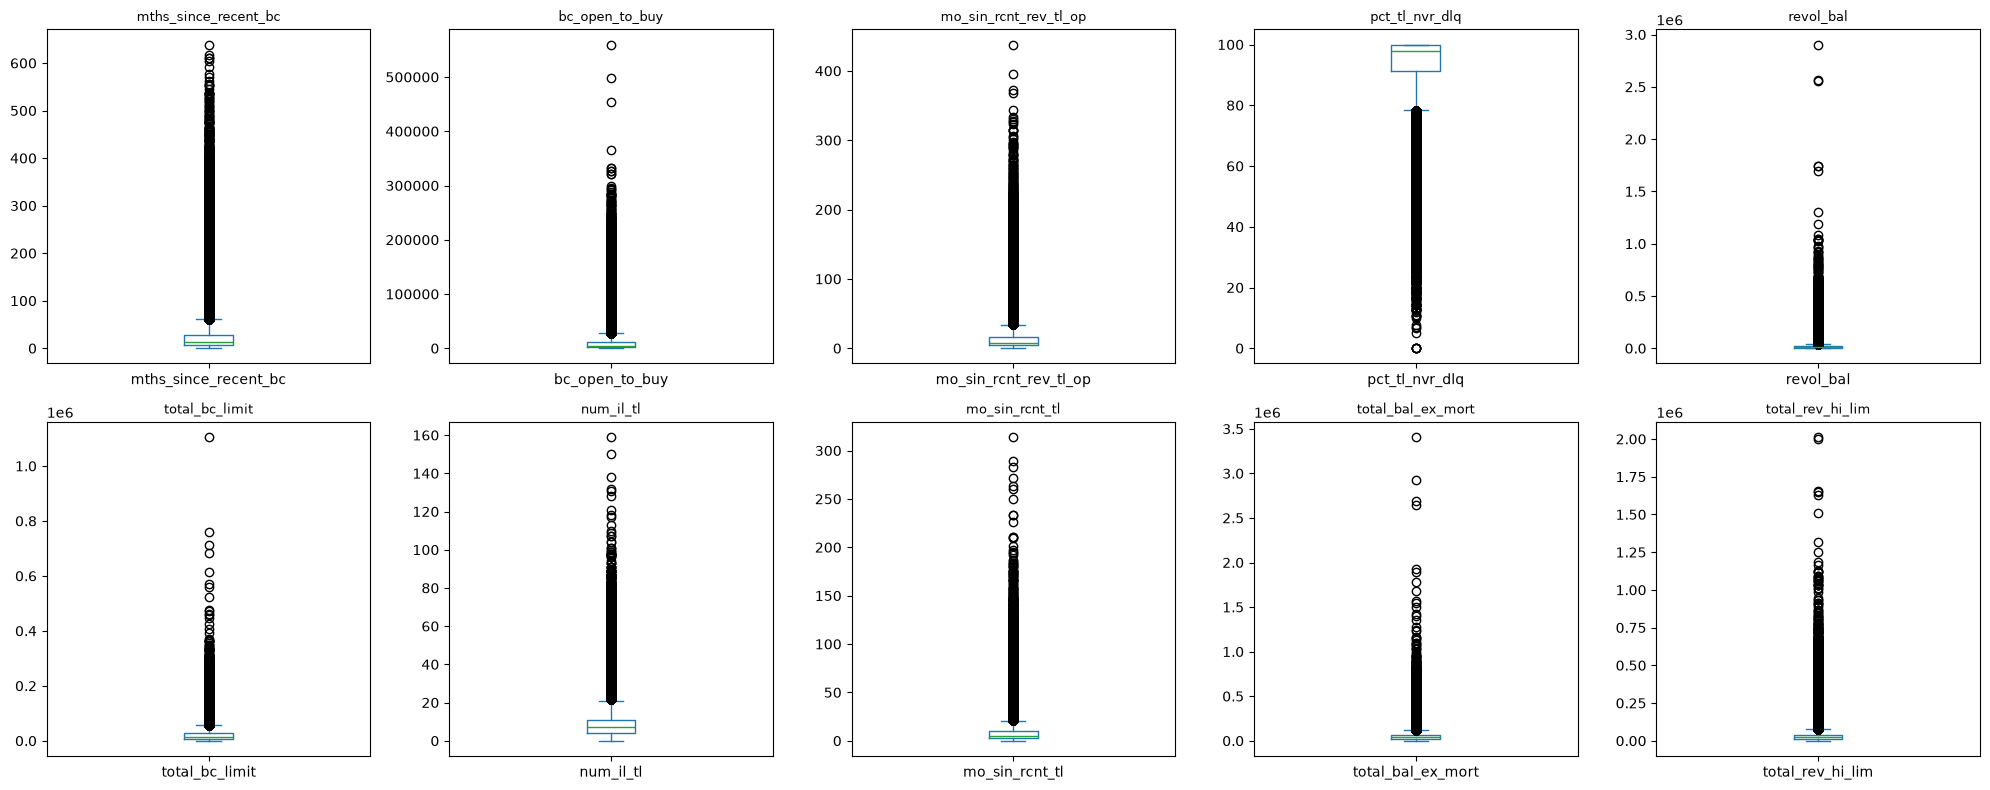

In [39]:
import matplotlib.pyplot as plt
# Plot top columns with the most outliers
# Use continuous_cols not numeric_cols
top_cols = outlier_summary.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flatten(), top_cols):
    df[col].plot(kind='box', ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

each of these columns has a tight box near zero/low values with a long tail of dots stretching upward, the visual signature of right-skew rather than random/corrupted data. This supports the decision to leave these columns untouched rather than removing or capping them.

## Class imbalance handling

In [47]:
# Check class distribution in your TRAINING set specifically
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

# Optionally also check test set, just to confirm it's proportionally similar
print(y_test.value_counts(normalize=True) * 100)

loan_status
0    861398
1    232053
Name: count, dtype: int64
loan_status
0    78.777924
1    21.222076
Name: proportion, dtype: float64
loan_status
0    78.778268
1    21.221732
Name: proportion, dtype: float64


At roughly 79/21, this falls into the "moderate imbalance" zone — not extreme (like 95/5), but real enough that a model trained naively could lean toward just predicting "no default" most of the time and still get ~79% accuracy while being nearly useless at catching actual defaults. So yes, it's worth addressing, but you don't need anything aggressive.

## Save the cleaned dataset to .csv file( train and test sets)

In [48]:
import os

# Create the processed subfolder inside your existing data folder
os.makedirs('data/processed', exist_ok=True)

# Now save as before
train_final = X_train.copy()
train_final['loan_status'] = y_train

test_final = X_test.copy()
test_final['loan_status'] = y_test

train_final.to_csv('data/processed/train_cleaned_accepted_loans.csv', index=False)
test_final.to_csv('data/processed/test_cleaned_accepted_loans.csv', index=False)

print(f"Train set saved: {train_final.shape}")
print(f"Test set saved: {test_final.shape}")

Train set saved: (1093451, 127)
Test set saved: (273366, 127)
